# CloudSat 3D U-Net Predictions Visualization
Run this notebook to visualize the original satellite chips, the true CloudSat labels, and our model's predictions side-by-side.

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import pytorch_lightning as L
import sys
sys.path.append('.') # Ensure we can import local modules

# Import models and datamodule
from models import LightningModel
from abidatamodule import AbiDataModule

# Configuration
datapath = '/explore/nobackup/projects/pix4dcloud/aliewehr/chipTests/chips/allChips'
TRAINING_SPLIT = (0, 0.8)
VAL_SPLIT = (0.8, 0.9)
TEST_SPLIT = (0.9, 1.0)
BATCH_SIZE = 1
DATALOADER_WORKERS = 8

# Cloud color map from presentable_vis.ipynb
cloud_colors = [
    "#777777",  # -1: missing retrieval
    "#ffffff",  #  0: valid clear
    "#66c2ff",  #  1 cirrus
    "#33a02c",  #  2 altostratus
    "#e31a1c",  #  3 altocumuls
    "#9467bd",  #  4 stratus
    "#8c564b",  #  5 stratocumulus
    "#e377c2",  #  6 cumulus
    "#bcbd22",  #  7 numbostratus
    "#17becf",  #  8 deep convection
]
cloud_cmap = ListedColormap(cloud_colors)
cloud_norm = BoundaryNorm(np.arange(-1.5, 9.5, 1), cloud_cmap.N)

/panfs/ccds02/app/modules/anaconda/platform/x86_64/rhel/8.6/3-2022.05/envs/ilab-pytorch/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")


### 1. Load the Test Data and Model

In [3]:
# Initialize datamodule
datamodule = AbiDataModule(
    data_path=datapath,
    train_split=TRAINING_SPLIT,
    val_split=VAL_SPLIT,
    test_split=TEST_SPLIT,
    batch_size=1,
    num_workers=DATALOADER_WORKERS
)
datamodule.setup('test')
# Using a fixed seed for reproducible test batches
torch.manual_seed(42)
test_loader = datamodule.test_dataloader()
data_iter = iter(test_loader)

# Load the best model checkpoint (Epoch 13)
checkpoint_path = "./checkpoints/unet3d_baseline/best-epoch=13-val_loss=0.37.ckpt"
model = LightningModel.load_from_checkpoint(checkpoint_path)
model.eval()
if torch.cuda.is_available():
    model = model.cuda()


/home/aliewehr/.local/lib/python3.9/site-packages/pytorch_lightning/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.5, which is newer than your current Lightning version: v2.6.0


### 2. Plotting Function

In [4]:
def plot_prediction(chip, true_mask, pred_mask, band_idx=12, frame_idx=3):
    # PyTorch 3D CNN shape: (B, C, T, H, W). 
    # C=16 (bands), T=7 (frames). Band 13 is index 12. Middle frame is 3.
    
    # We grab the specified band/frame for the first item in the batch
    img_data = chip[0, band_idx, frame_idx, :, :]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)
    
    # Plot input chip (middle frame)
    axes[0].imshow(img_data, cmap='gray')
    axes[0].set_title(f'ABI Input (Frame {frame_idx}, Band {band_idx+1})')
    
    # Plot True Mask
    # Transposing to match the orientation in presentable_vis.ipynb
    im1 = axes[1].imshow(true_mask[0].T, cmap=cloud_cmap, norm=cloud_norm, origin='lower', aspect='auto')
    axes[1].set_title('True CloudSat Mask')
    axes[1].set_xlabel("Distance along track")
    axes[1].set_ylabel("Altitude")
    
    # Plot Predicted Mask
    im2 = axes[2].imshow(pred_mask[0].T, cmap=cloud_cmap, norm=cloud_norm, origin='lower', aspect='auto')
    axes[2].set_title('Predicted Mask')
    axes[2].set_xlabel("Distance along track")
    
    # Add colorbar
    cbar = fig.colorbar(im1, ax=axes, orientation='horizontal', pad=0.15, fraction=0.05)
    cbar.set_label("Cloud Class")
    
    plt.tight_layout()
    plt.show()

### 3. Generate Predictions and Visualize
Run this cell multiple times to iterate through the test set and see new predictions!

/explore/nobackup/people/aliewehr/.nccstmp/ipykernel_2680943/3998805573.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


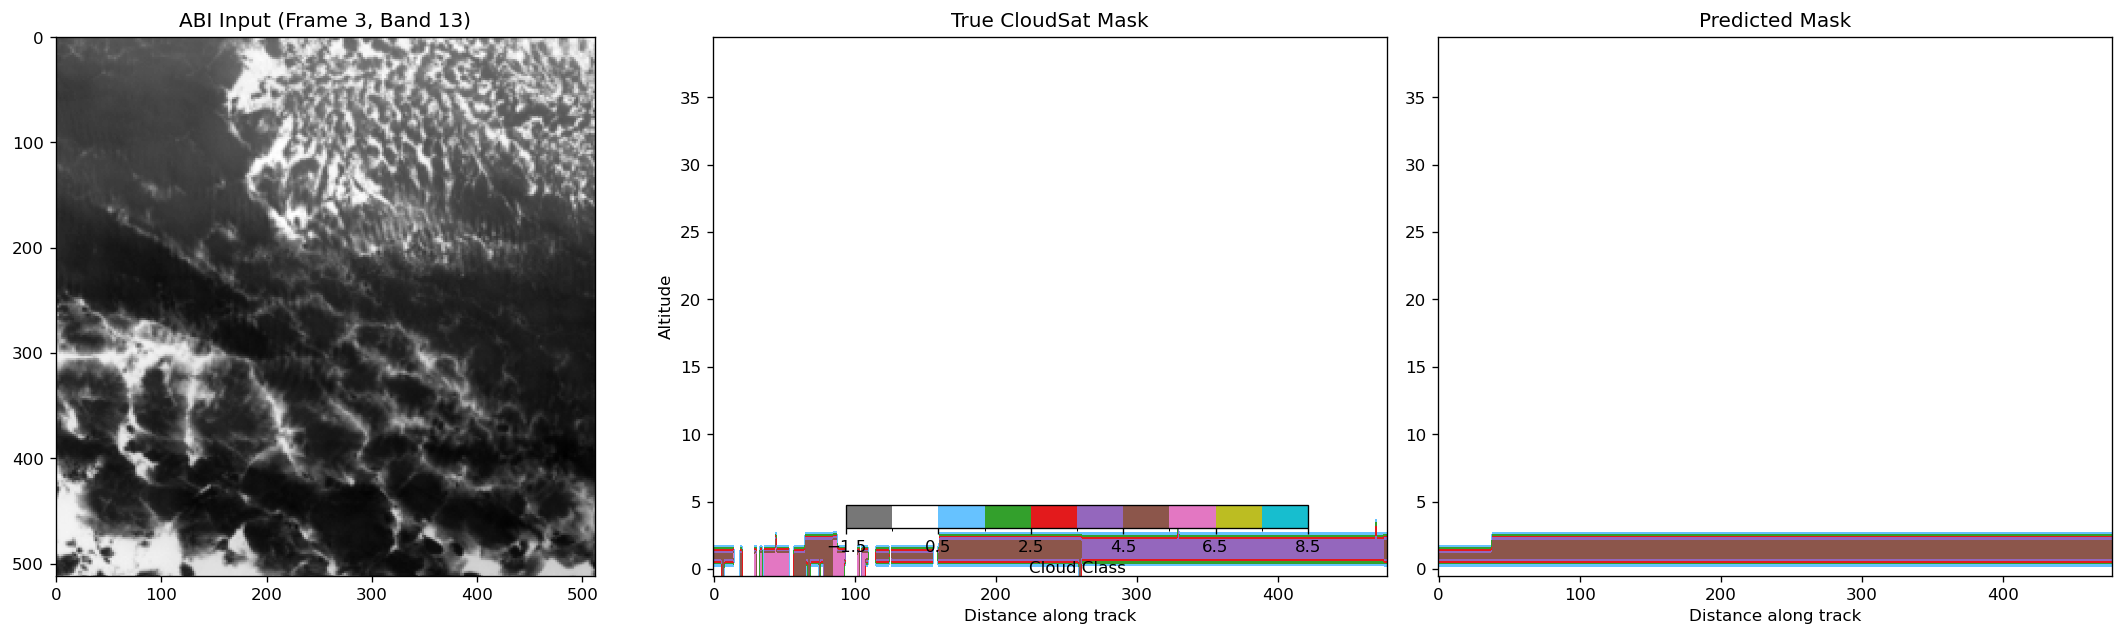

In [19]:
# Grab the next batch
try:
    batch = next(data_iter)
except StopIteration:
    print("Reached the end of the test set!")
    data_iter = iter(test_loader)
    batch = next(data_iter)
    
chips, true_masks = batch['chip'], batch['mask']

# Get predictions
with torch.no_grad():
    if torch.cuda.is_available():
        chips = chips.cuda()
    logits = model(chips)
    pred_masks = torch.argmax(logits, dim=1).cpu()
    chips = chips.cpu()

plot_prediction(chips.numpy(), true_masks.numpy(), pred_masks.numpy())